## Lab 1: Statistical Inference, Sample Comparisons, A/B Testing ##

**By Fiona St. Clair**

**Generative AI Disclosure**: I used Claude (Cowork) as a tutor throughout this lab to help me understand new concepts and debug my own code — not to write my analysis for me. Specifically, Claude explained statistical concepts I hadn't encountered before (the logic behind `proportions_ztest`, Levene's test, ANOVA, Tukey's HSD, and statistical power/MDE calculations), walked me through pandas/statsmodels syntax I was unfamiliar with (`.dropna(subset=...)`, `pd.crosstab`, `.groupby()`, regex-based text cleaning, `.map()`), and helped me debug errors in my own code (a mismatched file path that caused a `KeyError`, a `SyntaxError` from a copy-paste mistake, and a mislabeled column check). For one visualization (the power curve in Activity 4, Question 3), I asked Claude to write the plotting code directly, adapting the structure from our in-class `statistical_power.ipynb` notebook to my specific numbers.

I checked correctness throughout by cross-referencing printed output against my plots (e.g., confirming crosstab counts matched what the boxplots showed), manually recalculating values Claude referenced (e.g., verifying Tukey's `meandiff` column against `groupby()` means by hand), and restarting my kernel and re-running the notebook top to bottom to confirm everything executed cleanly from a fresh state. All written interpretations and conclusions are my own reasoning. Per the syllabus policy, I did not use Claude for any of the reflection questions — those responses reflect only my own thinking.

***

**Activity 1: Comparing two proportions**

Using the Palmer penguins dataset, we want to explore comparing two proportions, which we did not get to in class. We answer the following question: Are penguins that live on Biscoe island larger? We want to look at the “rate” of large penguins on Biscoe vs the other two islands. Please use the following 
definitions and resources: 
- What does larger mean? For any penguin, is it larger than median penguin body mass. We can write this as: `peng["is_large"] = peng["body_mass_g"] > peng["body_mass_g"].median()`
- You are going to want to look at the fraction of large penguins on Biscoe island vs large penguins  on other islands 
- Stats models has a proportions_ztest function that will be useful for this exercise 
- The pandas crosstab function might also be useful 
 
Please complete the following:

1. [2pts] Visualize body mass of the penguins across different islands. What does this tell you? 
- ***From the boxplot, we can see that Biscoe penguins are by far the largest with a mean of around 4750 grams. Torgersen and Dream penguins come behind in a close tie with nearly the same average weight of around 3750 grams. Biscoe penguins have the largest range in weights across the different islands, and there is a random outlier Dream penguin that weighs much more than their peers.***
2. [3pts] Using the definitions above, answer the question: Are penguins on Biscoe island larger?  
- ***z-stat = 10.809691047645456 (10.81 points above mean), p-value = 1.5485568601590401e-27 (statistically significant, reject the null)***
    - ***nO = rate of large penguins is the same across all islands***
    - ***n1 = rate of large penguins is NOT the same across all islands***
-  ***Because our p-value is statistically significant, we reject the null hypothesis, and therefore can reason that there is a statistically significant difference in the rate of large penguins acorss all islands.***
3. [2pts] Now visualize which species of penguins live on each island. How does that change your answer to the question: Are penguins on Biscoe island larger?  
- ***After splitting the penguins up by island AND species, it is clear that is it not the island that creates the change, but rather the species. Gentoo penguins only reside on Biscoe Island and are by far the largest penguins and are therefore skewing their data heavily.***
4. [3pts] Repeat the proportion test considering only one species of penguin. Which species did you choose, and how did that impact your answer? 
- ***I chose Adelie penguins, as they are the only penguins that live on all three islands. After running the test, it returned a z statistic of -0.267 and a p-value of 0.605, and because p-value is larger than .05, we fail to reject the null hypothesis, meaning there is not enough evidence to reason that Adelie penguins on Biscoe have a different rate of size that Adelie penguins on other islands.***

In [133]:
import os
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind as sm_ttest
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
os.getcwd()

# question 1

peng = pd.read_csv("../../data/penguins.csv")
peng["is_large"] = peng["body_mass_g"] > peng["body_mass_g"].median() # from lab
peng = peng.dropna(subset=["body_mass_g"]) # drop rows with missing body mass
print(peng.shape)
peng.head()

(342, 9)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,is_large
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,False
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,False
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,False
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,False
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,False


In [134]:
print(peng["island"].value_counts(dropna=False))

island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64


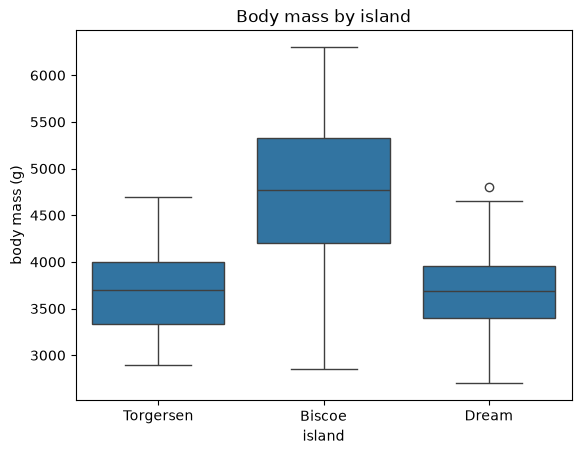

In [135]:
sns.boxplot(
    data=peng.dropna(subset=["island"]),
    x="island",
    y="body_mass_g",
)
plt.ylabel("body mass (g)")
plt.title("Body mass by island")
plt.show()

In [136]:
# question 2
biscoe_large = peng.loc[peng["island"] == "Biscoe", "is_large"].sum() # sum of large penguins on Biscoe
biscoe_n = (peng["island"] == "Biscoe").sum() # total number of penguins on Biscoe

other_large = peng.loc[peng["island"] != "Biscoe", "is_large"].sum() # sum of large penguins on other islands
other_n = (peng["island"] != "Biscoe").sum() # total number of penguins on other islands

z_stat, p_value = proportions_ztest(
    count=[biscoe_large, other_large],
    nobs=[biscoe_n, other_n],
    alternative="larger"
)

print(z_stat, p_value)

10.809691047645456 1.5485568601590401e-27


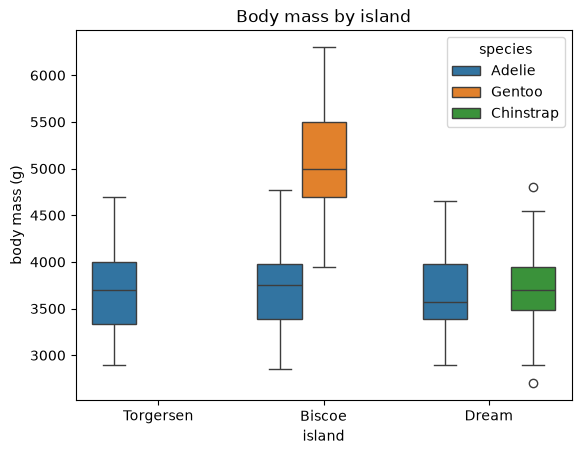

In [137]:
# question 3

sns.boxplot(
    data=peng.dropna(subset=["island"]),
    x="island",
    y="body_mass_g",
    hue="species",
)
plt.ylabel("body mass (g)")
plt.title("Body mass by island")
plt.show()

In [138]:
pd.crosstab(peng["island"], peng["species"])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,123
Dream,56,68,0
Torgersen,51,0,0


In [139]:
# question 4

adelie = peng.loc[peng["species"] == "Adelie"]

biscoe_large = adelie.loc[adelie["island"] == "Biscoe", "is_large"].sum()
biscoe_n = (adelie["island"] == "Biscoe").sum()

other_large = adelie.loc[adelie["island"] != "Biscoe", "is_large"].sum()
other_n = (adelie["island"] != "Biscoe").sum()

z_stat, p_value = proportions_ztest(
    count=[biscoe_large, other_large],
    nobs=[biscoe_n, other_n],
    alternative="larger"
)

print(z_stat, p_value)

-0.266904085463221 0.6052284945104162


***

**Activity 2: Digging Further into ANOVA with class data**

In class, we looked a little bit at our class data to explore whether and how average number of hours of sleep per night as a function of years since undergrad.  

1. [2 points] Re-bin the data into three groups instead of 5: [<1 year | 1-3 years | 4+ years] and plot hours of sleep for these three groups.  
2. [2 points] Repeat the test for equal variance with these three groups, as well as the ANOVA. What conclusions can you draw? Are any other assumptions violated?
    - ***levene p-value = 0.7500355905249032, fail to reject null, meaning the three groups have roughly the same spread of sleep hours***
    - ***anova p-value = 0.291179, fail to reject null, meaning average sleep hours do not necessarily differ across the three groups***
    - ***There are three other observations that can be noted about this data. Firstly, more than half of the students consist of recent undegrads, resulting in a much larger bin for the category. Next, there are two major outliers in the 4+ and <1 year categories that are unusually low. Finally, the median lines for each box do not sit in the middle of the box, signifying a small skew within the data.***
3. [4 points] Reflection: One thing we have been ignoring in this analysis is the fact that these are ordered variables: e.g. they aren’t independent buckets like in our penguins dataset where the different species have no inherent ordering. Here, <1 year means something in relation to 1-3 years and so forth. Please answer the following questions: 

    - a. How are the original buckets reflective of a poor survey design?  
        - ***Buckets in analysis cause issues because they essenially force someone's hand when answering a question and strip their true answer. It also forces very separate answers to possibly be forced together. For example, someone 4 years out of undergrad and 20 years out of undergrad are very different, yet in this survey, they are grouped together.***
    - b. Does splitting our data into three buckets vs five improve the survey design?  
        - ***Truly, no, this wouldn't improve anything. The best solution would be to make it a fully individual entry. For the example listed above, it could be changed to "what month and year did you gradaute undergrad?" instead. This way, there is a concreate answer from every individual person.***
    - c. If we were redesigning this survey, what would you recommend in order to answer the question about whether or not students who graduated more recently get more or less sleep than students who graduated longer ago?   
        - ***As mentioned above, I would first change the graduation question to ask when they graduated (mm/yyyy). I would also ask on average how many hours of sleep they get (in parenthesis, answer with ONE number, or a validation rule).***

4. [2 points] Reflection: We’ve been using the in-class survey data to help understand concepts around statistical inference, sample comparisons, and data cleaning. Is this a good dataset to help understand these concepts? Please explain why or why not, and reflect on what this might tell you more broadly about data collection, survey design, and drawing conclusions from a particular set of data.
    - ***I think this is a good data set to do so because it purposely made data collection mistakes to teach us the correct ways to do so in the future. For example, the number of hours of sleep should be validated to only have one number and not text responses like some people did. It teaches us the importance of not only collecting data, but making sure the survey/data collection method we use is absolutely foolproof before we deploy it, or else it will be a huge headache later.***


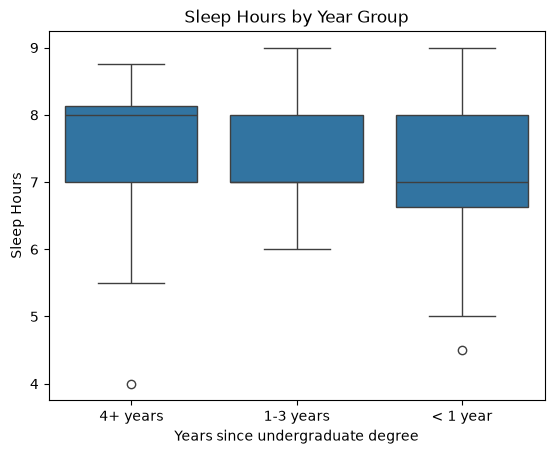

In [140]:
# question 1

df_sleep = pd.read_csv("../../data/DS6021-Fall26-Anonymized.csv")   
df_sleep["How many hours do you sleep in a typical night?"].unique()
sleep_hrs = df_sleep["How many hours do you sleep in a typical night?"].str.replace("hours", "").str.strip()
df_sleep["sleep_hrs"] = sleep_hrs

bounds = df_sleep["sleep_hrs"].str.extractall(r"(\d+\.?\d*)")[0].astype(float) #lines from class
df_sleep["sleep_hrs"] = bounds.groupby(level=0).agg(lambda x: x.head(2).mean())

year_map = {
    "< 1 year": "< 1 year",
    "1-3 years": "1-3 years",
    "4-6 years": "4+ years",
    "7-10 years": "4+ years",
    "10+ years": "4+ years",
}

df_sleep["year_group"] = df_sleep["How many years ago did you receive your undergraduate degree?"].map(year_map)

sns.boxplot(
    data=df_sleep.dropna(subset=["year_group", "sleep_hrs"]),
    x="year_group",
    y="sleep_hrs",
)
plt.xlabel("Years since undergraduate degree")
plt.ylabel("Sleep Hours")
plt.title("Sleep Hours by Year Group")
plt.show()

In [141]:
# question 2

group1 = df_sleep.loc[df_sleep["year_group"] == "< 1 year", "sleep_hrs"]
group2 = df_sleep.loc[df_sleep["year_group"] == "1-3 years", "sleep_hrs"]
group3 = df_sleep.loc[df_sleep["year_group"] == "4+ years", "sleep_hrs"]

levene_result = stats.levene(group1, group2, group3)
print(levene_result.pvalue)

model = ols("sleep_hrs ~ C(year_group)", data=df_sleep).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

df_sleep["year_group"].value_counts()

0.7500355905249032
                  sum_sq    df         F    PR(>F)
C(year_group)   2.516123   2.0  1.252339  0.291179
Residual       83.379226  83.0       NaN       NaN


year_group
< 1 year     50
4+ years     19
1-3 years    17
Name: count, dtype: int64

***

**Activity 3: Migraine Drug Formulations**

A pharmaceutical company tested three formulations of a pain relief medicine for migraine headache sufferers. 27 volunteers were selected and 9 were randomly assigned to one of the three drug 
formulations. Subjects took the drug during their next migraine episode and reported pain on a 1–10 scale (1 = no pain, 10 = extreme pain) 30 minutes after taking the drug. The dataset, Clinical_trial, contains the results of this experiment. 

Note: Some of the questions are purposefully left open-ended as there are multiple approaches to solve these problems. 

1. [2pts] Visualize the pain ratings across the three drug formulations. Provide a brief interpretation of what the graph reveals. 
    - ***Using a boxplot, we are able to see that drug A has the lowest average pain rating while drugs B and C have relatively the same pain level. Drug B, however, has the only major outlier of the data, with a level 8 entry.***
2. [5pts] As the Data Scientist on a team of researchers at the pharmaceutical company, your main task is to evaluate which drug formulation most effectively reduces migraine pain. Formulate the appropriate hypotheses, perform the relevant statistical test(s), and communicate each step of your analysis and results in clear, accessible written language for non-technical team members.
    - ***anova p-value = 0.000256, reject the null, so at least one of the drugs produces a meaningfully different average pain rating.***
    - ***tukey test = drug A patients reported noticebly less pain than the other two groups (and those two groups were indistinguishable from one another).*** 
    - ***Non-technical: Through these two tests, we have found that at least one of the drugs produces a meaningfully different average pain rating compared to the other two. We have also found that drug A recipients reported noticebly less pain than the other two groups, which were indistinguishable from one another. With those findings, we can move forward with reasoning that drug A has a lower pain level overall and is superior to the other drugs.*** 
3. [3pts] Suppose we wanted to build a supervised learning model using this dataset. What would be the prediction goal? Note that you do not have to build a predictive model to answer this question. Discuss in what situations a pharmaceutical company might use statistical inference vs prediction.
    - ***Turning this into a supervised learning model, the overall prediction goal would be to predict patient's individual pain ratings on a given drug (so what fits them best). The features needed would be the data from the patient themself and other patients (hopefully more than 27...). This would also have to be a regression model because it is modeling the pain scale rather than a classification situation.***
    - ***An inference would be the better option if the data we had was smaller (like we have now) or not good data, or it is a one time population decision. A prediction model would be better if it we had a lot more data that was much more dense, or if we were analyzing a specific case.***

<Axes: xlabel='Drug', ylabel='Pain_Rating'>

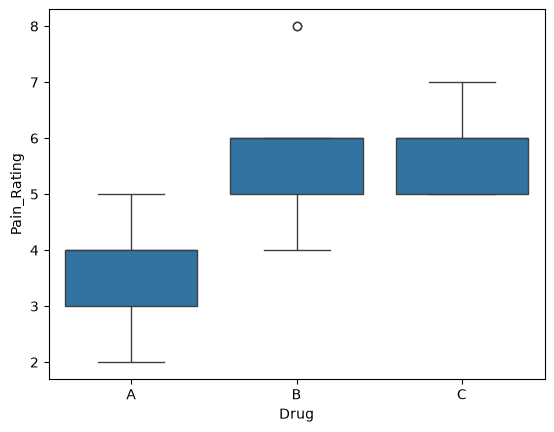

In [142]:
# question 1

drug = pd.read_csv("../../data/Clinical_trial.csv")
drug

drug.groupby("Drug")["Pain_Rating"].mean()
sns.boxplot(data=drug, x="Drug", y="Pain_Rating")

In [143]:
# question 2

model = ols("Pain_Rating ~ C(Drug)", data=drug).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

tukey_result = pairwise_tukeyhsd(drug["Pain_Rating"], drug["Drug"], alpha=0.05)
print(tukey_result)

drug.groupby("Drug")["Pain_Rating"].mean()

             sum_sq    df         F    PR(>F)
C(Drug)   28.222222   2.0  11.90625  0.000256
Residual  28.444444  24.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   2.1111 0.0011  0.8295 3.3927   True
     A      C   2.2222 0.0006  0.9406 3.5038   True
     B      C   0.1111 0.9745 -1.1705 1.3927  False
---------------------------------------------------


Drug
A    3.666667
B    5.777778
C    5.888889
Name: Pain_Rating, dtype: float64

***

**Activity 4: Statistical Power**

In class, we did some simulations to explore concepts around statistical power. We specifically looked at an example of an A/B test to understand how long it would take us to detect a 5% difference in average sales when comparing two websites. Now let’s assume you are presented with the following scenario:  
 
A business analyst (BA) comes to you needing help making a decision. So far, they have been running an A/B test for 4 days between two versions of an app, and they want to look at the mean length of time spent on the app, with more time being better. They have presented you with the following information: 
- Each day, 300 users are in the control (A) and treatment (B) groups.  
- A is the version of the app currently in production, and users typically spend an average of 12 minutes on the App with a standard deviation of +/- 4 minutes.  
- After running this A/B test for 4 days, they have observed that users who receive version B of the app spend an average of 12.5 minutes on the App vs 12 for version A. This BA is getting some pressure from their leadership to move everyone to version B of the app, but they want you to tell them whether or not they can trust the results they have so far.  
 
1. [3pts] Assuming an alpha of 0.05 and a power of 0.8, what is the minimum effect size we could measure after 4 days? 
    - ***The smallest real difference in average time-on-app that the test could actually detect is about 0.46 minutes (around 27 seconds).***
2. [3pts] Based on your answer to the first question, would you recommend discontinuing the A/B test and moving everyone to the B version of the app? If yes, why? If not, why not?  
    - ***I would not recommend ending the testing and switching yet because the the difference between my result (.46) and their results (.5) is so small, we cannot reliably say there is any change happening. It would be best to continue to test and keep collecting data.***
3. [5pts] Create a visualization and three bullet points that you could present to leadership about your analysis to help them make a decision.  
    - ***The observed difference of 0.5 minutes is only slightly larger than the smallest difference our test is currently capable of detecting reliably, so we can't yet be confident this reflects a real improvement rather than random variation.***
    - ***At this time, we propose to extend this testing for another 2 weeks to collect further data and re-evaluate our findings.***
    - ***Extending the test to 18 total days would lower the smallest difference we could reliably detect from about 0.46 minutes to about 0.22 minutes, meaning we'd be able to confidently confirm (or rule out) even a modest improvement, rather than relying on a result that's currently right at the edge of what our test can detect.***
4. [4pts] What if your BA collaborator came back to you and said the test was being discontinued (regardless of your analysis)—how would that change how you frame the results to leadership?
    - ***I'm not too sure how I would attack this, but I would lean most on the last bullet point I provided to leadership and reason with them a timeline to make sure they are making the right decision. Because we made a visualization of our work, we can chose a different time that falls on that graph, but I would want them to fully understand what they are taking on my making such a decision.***

In [144]:
# question 1

from statsmodels.stats.power import TTestIndPower
analysis = TTestIndPower()

d = analysis.solve_power(effect_size=None, nobs1=1200, alpha=0.05, power=0.8, ratio=1.0, alternative="two-sided")
print(d)

0.11441992802911244*4

d = analysis.solve_power(effect_size=None, nobs1=5400, alpha=0.05, power=0.8, ratio=1.0, alternative="two-sided")
print(d)

0.053920895254915766*4

0.11441992802911244
0.053920895254915766


0.21568358101966306

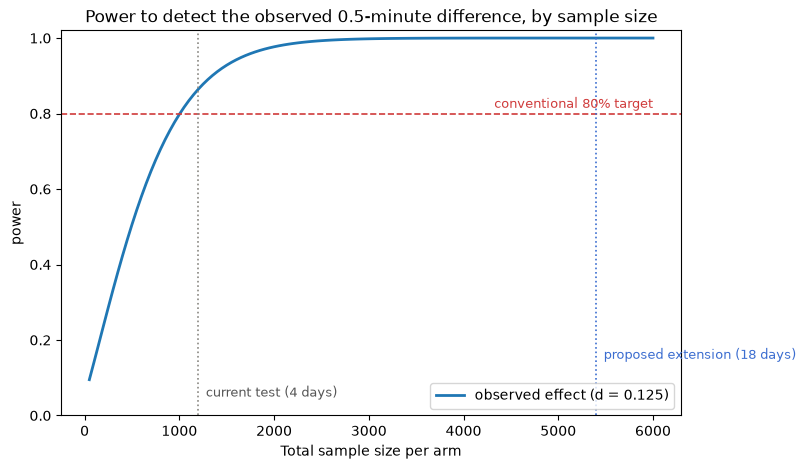

In [ ]:
# question 3 and 4
# I have never used this library to this extend before, but I tried to model it off of the one from the statistical_power.ipynb with AI's help

import numpy as np
import matplotlib.pyplot as plt

SD_TIME = 4
OBSERVED_DIFF = 0.5

observed_d = OBSERVED_DIFF / SD_TIME

n_grid = np.arange(50, 6001, 50)

power_curve = analysis.power(effect_size=observed_d, nobs1=n_grid, alpha=0.05, ratio=1.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_grid, power_curve, linewidth=2, label=f"observed effect (d = {observed_d:.3f})")

ax.axhline(0.80, color="#d03b3b", linestyle="--", linewidth=1.2)
ax.text(6000, 0.815, "conventional 80% target", ha="right", color="#d03b3b", fontsize=9)

ax.axvline(1200, color="#898781", linestyle=":", linewidth=1.2)
ax.text(1200 + 80, 0.05, "current test (4 days)", color="#555555", fontsize=9)

ax.axvline(5400, color="#3b6dd0", linestyle=":", linewidth=1.2)
ax.text(5400 + 80, 0.15, "proposed extension (18 days)", color="#3b6dd0", fontsize=9)

ax.set_xlabel("Total sample size per arm")
ax.set_ylabel("power")
ax.set_ylim(0, 1.02)
ax.set_title("Power to detect the observed 0.5-minute difference, by sample size")
ax.legend(loc="lower right")
plt.show()